<a href="https://colab.research.google.com/github/erickvaldezsallagos/PROCESOS-ESTOCASTICOS/blob/main/CAMINATA_ALEATORIA(correcta).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caminata aleatoria 1D

# Definición del problema

Implementar una caminata aleatoria 1D, con probabilidad p de moverse a la derecha y probabilidad q de moverse a la izquierda, tal que $$p + q = 1.$$



In [38]:
import numpy as np
import matplotlib.pyplot as plt

Definimos una secuencia de variables aleatorias $X_1, X_2, \dots, X_n$ donde cada $X_i$ representa un paso.

Definimos la función para la pisición final
$$ x_i = +1 \hspace{0.2cm}{\text{con probabilidad p a la derecha}}  $$
$$ x_i = -1 \hspace{0.2cm}{\text{con probabilidad q a la izquierda}}  $$

In [39]:
def caminata_aleatoria_(n_pasos, p):
    """
    Simula una caminata aleatoria en 1D.
    n_pasos: Número total de pasos.
    p: Probabilidad de moverse a la derecha (+1).
    """
    q = 1 - p
    # Generamos los pasos: +1 o -1 basados en la probabilidad p
    pasos = np.random.choice([1, -1], size=n_pasos, p=[p, q])

    # La trayectoria es la suma acumulada de los pasos
    trayectoria = np.cumsum(pasos)
    # Insertamos el origen (0) al inicio
    trayectoria = np.insert(trayectoria, 0, 0)

    return trayectoria

La posición final $S_n$ tras $n$ pasos se define como

$$ S_n = \sum_{i=1}^n X_i $$

Definimos los parámetros

In [40]:
# Parámetros de la simulación
N = 100    # Número de pasos
P_DERECHA = 0.5  # Ligeramente sesgado a la derecha

Ejecutamos la funcion

In [26]:
# Ejecución
recorrido = caminata_aleatoria_(N, P_DERECHA)

Implementación gráfica

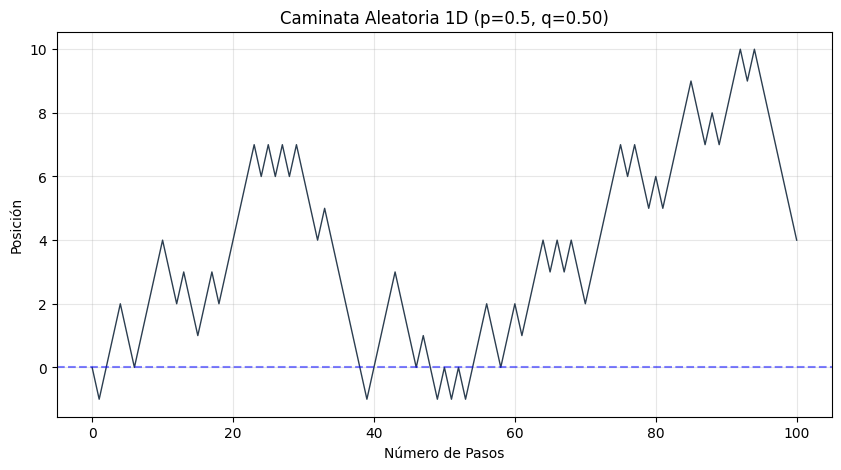

In [27]:
# Visualización
plt.figure(figsize=(10, 5))
plt.plot(recorrido, color='#2c3e50', linewidth=1)
plt.axhline(0, color='blue', linestyle='--', alpha=0.5)
plt.title(f"Caminata Aleatoria 1D (p={P_DERECHA}, q={1-P_DERECHA:.2f})")
plt.xlabel("Número de Pasos")
plt.ylabel("Posición")
plt.grid(True, alpha=0.3)
plt.show()

# Conclusiones

In [28]:
def caminata_aleatoria(n,p):
  posicion=0
  camino=[posicion]
  for i in range(n):
    a=random.random() #Generamos números aleatorios entre 0,1
    if a < p:
      posicion=posicion+1 #Éxito: sube
    else:
      posicion=posicion-1 #Fracaso: baja
    camino.append(posicion)
  plt.plot(camino, color='blue')
  plt.title("Caminata Aleatoria")
  plt.xlabel("Número de pasos")
  plt.ylabel("Posición")
  plt.axhline(0.0, linestyle='--', color='red')
  plt.grid(True)
  plt.show()

  return camino

# ***1.Con una probabilidad igualatoria.  ¿Cuál es la probabilidad de que la partícula regrese al origen?***


*   Elemento de lista
*   Elemento de lista



Solucion y respuesta:

In [29]:
import random
def caminata_aleatoria_datos(n,p):
    posicion=0
    camino=[posicion]
    for i in range(n):
        a=random.random()
        if a < p:
            posicion=posicion+1
        else:
            posicion=posicion-1
        camino.append(posicion)
    return camino

Se vuelve a llamar a la función
“caminata_aleatoria” pero sin el apartado
que grafica para así solo analizar los datos
y se cambia a nombre para que no afecte si
posteriormente se desea graficar
nuevamente

In [30]:
def origen(m, n, p):
    ceros = []

    for i in range(m):
        camino = caminata_aleatoria_datos(n, p)
        cantidad_ceros = camino.count(0)
        ceros.append(cantidad_ceros)

    promedio = np.mean(ceros)
    return print("El promedio de veces que la partícula regresa al origen es: ", promedio)

Se crea la función “origen” que realiza m
iteraciones de la función
caminata_aleatoria, cuenta los 0 que hay en
cada iteración, los guarda en una lista y
posteriormente obtiene el promedio de
dicha lista

In [31]:
m=100
n=100
p=0.5
origen(m, n, p)

El promedio de veces que la partícula regresa al origen es:  8.21


Aquí el promedio de la lista con m valores,
en cada iteración cambia, pero dicho
promedio se encuentra aproximadamente
entre un rango de [6, 9], esto cuando
p = 0.5, son equiprobables

# ***2. Si se tiene un n pequeño ¿se ve muy afectada la trayectoria si se favorece con probabilidad a izquierda o derecha?***

Solución:

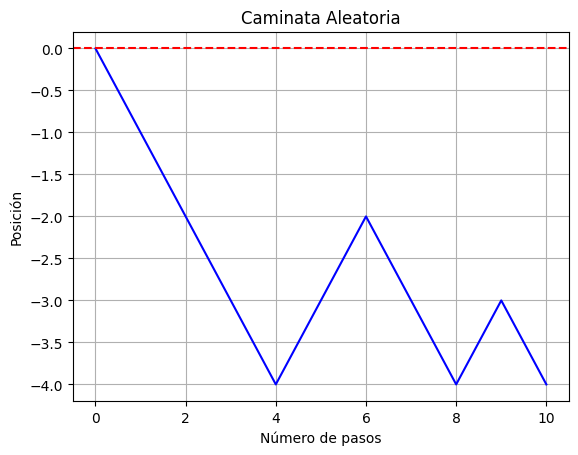

[0, -1, -2, -3, -4, -3, -2, -3, -4, -3, -4]

In [32]:
n=10
p=0.2
caminata_aleatoria(n, p)

Gráfica con n, p pequeños, aunque la
probabilidad favorezca al lado izquierda,
por los pocos pasos que se dan, tiende a
comportarse de manera no tan esperada

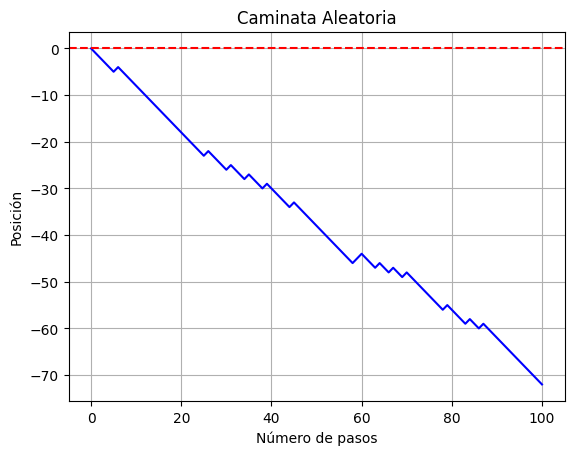

In [33]:
n=100
p=0.2
_=caminata_aleatoria(n,p)

Si influye n en la vista de la trayectoria, ya
que con un n alejado de la media, el
recorrido puede arrojar un comportamiento
parecido al de un p equitativo, por otro lado
para un n grande se aprecia la ventaja
hacia el lado izquierdo cuando p es
pequeño. De manera análoga si p es grande

# ***3. ¿Cuál es la máxima distancia que alcanza con p igualitaria?***

In [34]:
def maximo(m, n, p):
    maximos = []

    for i in range(m):
        camino = caminata_aleatoria_datos(n, p)
        max_caminata = max(camino)
        maximos.append(max_caminata)

    promedio = np.mean(maximos)
    return print("El máximo promedio de la caminata es: ", promedio)

Se crea una función análoga a la que busca
los ceros, pero en esta ocasión, busca al
máximo de cada iteración, los enlista y se
saca el promedio

In [35]:
m=100
n=100
p=0.5

maximo(m,n,p)

El máximo promedio de la caminata es:  7.84


Se aprecia que el máximo parece tener una
cota, ya que no crece de manera
exponencial, esto también es debido a la
probabilidad igualitaria, en otro caso, el
máximo tiende a aumentar

# ***4. ¿Cuál es la mínima distancia que alcanza con p igualitario?***

Solución y respuesta:

In [36]:
def minimo(m, n, p):
    minimos = []

    for i in range(m):
        camino = caminata_aleatoria_datos(n, p)
        min_caminata = min(camino)
        minimos.append(min_caminata)

    promedio = np.mean(minimos)
    return print("El mínimo promedio de la caminata es: ", promedio)

Se crea una función análoga a la de
máximos, pero en esta ocasión, busca al
mínimo

In [37]:
m=100
n=100
p=0.5

minimo(m,n,p)

El mínimo promedio de la caminata es:  -6.97


Aquí se observa un dato muy interesante, el
cual es que el promedio de máximos y
mínimos pareciera ser en forma de espejo,
ya que ambos oscilan entre aproximandamente los mismos
valores pero con signo contrario